# Loan Sanction Prediction — End-to-End Data Science Project

## Project Overview

This project focuses on analyzing historical loan application data and building a machine learning model to predict whether a loan application will be approved.

The project will cover the complete data science workflow:

1. Data understanding
2. Data cleaning
3. Exploratory data analysis (EDA)
4. Feature engineering
5. SQL analysis
6. Machine learning model development
7. Model evaluation and comparison
8. Prediction on unseen data
9. Model interpretation
10. Power BI dashboard
11. Project documentation for GitHub

### Dataset

The dataset is divided into two files:

- `loan_sanction_train.csv` — historical loan applications containing the target variable `Loan_Status`.
- `loan_sanction_test.csv` — loan applications without the target variable, which will be used for final predictions.

### Machine Learning Objective

The objective is to build a supervised machine learning classification model that predicts whether a loan application will be approved (`Y`) or rejected (`N`).

In [456]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
warnings.filterwarnings('ignore')

base_dir = Path.cwd()
if not (base_dir / "Data").exists():
    base_dir = base_dir.parent

train = pd.read_csv(base_dir / "Data" / "loan_sanction_train.csv")
unseen = pd.read_csv(base_dir / "Data" / "loan_sanction_test.csv")


In [457]:
train.shape

(614, 13)

In [458]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Dataset Structure

The training dataset contains historical loan applications along with their loan approval status.

The test dataset contains similar applicant information but does not contain `Loan_Status`. This allows the trained machine learning model to generate predictions for unseen applications.

The training dataset contains 614 records and 13 columns, while the test dataset contains 367 records and 12 columns.

In [459]:
train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

## 2. Target Variable

The target variable for this project is `Loan_Status`.

It represents the final loan decision:

- `Y` — Loan approved
- `N` — Loan rejected

The remaining applicant characteristics will be used as predictor variables to train the machine learning models.

In [460]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [461]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [462]:
train.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## 3. Missing Value Investigation

The training dataset contains missing values in several predictor variables. Before imputing these values, the missing records will be investigated to understand their distribution and determine an appropriate treatment strategy.

The target variable, `Loan_Status`, contains no missing values, which means all training records have a known outcome.

In [463]:
missing_rows = train[train.isna().any(axis=1)]

missing_rows.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N


In [464]:
missing_rows.shape

(134, 13)

In [465]:
missing_rows.isna().sum().sort_values(ascending=False)

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

In [466]:
missing_rows.isna().sum(axis=1).value_counts().sort_index()

1    121
2     11
3      2
Name: count, dtype: int64

In [467]:
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(train[col].value_counts(dropna=False))


--- Gender ---
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

--- Married ---
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

--- Dependents ---
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

--- Education ---
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

--- Self_Employed ---
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

--- Property_Area ---
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


In [468]:
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

train[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 4. Missing Values and Loan Approval

Before imputing missing values, we investigate whether the absence of information is associated with the loan approval outcome.

This helps determine whether missingness is random or whether it may contain useful information about the applicant.

The target variable `Loan_Status` is used only for investigation at this stage. No imputation or model training is performed yet.

In [469]:
missing_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in missing_cols:
    print(f"\n--- {col} ---")
    
    missing = train[train[col].isna()]
    not_missing = train[train[col].notna()]
    
    print("Missing:", len(missing))
    print("Missing approval rate:")
    print(missing['Loan_Status'].value_counts(normalize=True))
    
    print("\nNot missing approval rate:")
    print(not_missing['Loan_Status'].value_counts(normalize=True))


--- Gender ---
Missing: 13
Missing approval rate:
Loan_Status
Y    0.615385
N    0.384615
Name: proportion, dtype: float64

Not missing approval rate:
Loan_Status
Y    0.688852
N    0.311148
Name: proportion, dtype: float64

--- Married ---
Missing: 3
Missing approval rate:
Loan_Status
Y    1.0
Name: proportion, dtype: float64

Not missing approval rate:
Loan_Status
Y    0.685761
N    0.314239
Name: proportion, dtype: float64

--- Dependents ---
Missing: 15
Missing approval rate:
Loan_Status
Y    0.6
N    0.4
Name: proportion, dtype: float64

Not missing approval rate:
Loan_Status
Y    0.689482
N    0.310518
Name: proportion, dtype: float64

--- Self_Employed ---
Missing: 32
Missing approval rate:
Loan_Status
Y    0.71875
N    0.28125
Name: proportion, dtype: float64

Not missing approval rate:
Loan_Status
Y    0.685567
N    0.314433
Name: proportion, dtype: float64

--- LoanAmount ---
Missing: 22
Missing approval rate:
Loan_Status
Y    0.5
N    0.5
Name: proportion, dtype: float64

N

In [470]:
pd.crosstab(
    train['Credit_History'],
    train['Loan_Status'],
    normalize='index'
)

Loan_Status,N,Y
Credit_History,,
0.0,0.921348,0.078652
1.0,0.204211,0.795789


## 5. Numerical Variable Investigation

The numerical variables are examined before imputation to identify skewness, unusual values, and the most appropriate measure for replacing missing observations.

Median-based imputation may be preferable for highly skewed variables because extreme values can strongly influence the mean.

In [471]:
train[['ApplicantIncome',
       'CoapplicantIncome',
       'LoanAmount',
       'Loan_Amount_Term']].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


In [472]:
train['LoanAmount'].value_counts().head(20)

LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
128.0    11
113.0    11
130.0    10
95.0      9
96.0      9
70.0      8
115.0     8
112.0     8
125.0     7
104.0     7
135.0     7
136.0     7
150.0     7
132.0     7
158.0     6
Name: count, dtype: int64

In [473]:
train['Loan_Amount_Term'].value_counts(dropna=False).sort_index()

Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    512
480.0     15
NaN       14
Name: count, dtype: int64

In [474]:
train[train['LoanAmount'].isna()][
    ['ApplicantIncome',
     'CoapplicantIncome',
     'LoanAmount',
     'Loan_Status']
]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Status
0,5849,0.0,NaN,Y
35,2275,2067.0,NaN,Y
63,4945,0.0,NaN,N
81,2395,0.0,NaN,Y
95,6782,0.0,NaN,N
102,13650,0.0,NaN,Y
103,4652,3583.0,NaN,Y
113,7451,0.0,NaN,Y
127,3865,1640.0,NaN,Y
202,3992,0.0,NaN,N


In [475]:
train.groupby(train['LoanAmount'].isna())[
    ['ApplicantIncome', 'CoapplicantIncome']
].median()

,ApplicantIncome,CoapplicantIncome
LoanAmount,,
False,3806.0,1221.0
True,3928.5,0.0


In [476]:
train['Loan_Amount_Term'].value_counts(dropna=False).sort_index()

Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    512
480.0     15
NaN       14
Name: count, dtype: int64

In [477]:
train['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [478]:
train['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

In [479]:
train['Loan_Amount_Term'].value_counts(dropna=False).sort_index()

Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    512
480.0     15
NaN       14
Name: count, dtype: int64

In [480]:
train[train['LoanAmount'].isna()][
    ['ApplicantIncome',
     'CoapplicantIncome',
     'LoanAmount',
     'Loan_Status']
]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Status
0,5849,0.0,NaN,Y
35,2275,2067.0,NaN,Y
63,4945,0.0,NaN,N
81,2395,0.0,NaN,Y
95,6782,0.0,NaN,N
102,13650,0.0,NaN,Y
103,4652,3583.0,NaN,Y
113,7451,0.0,NaN,Y
127,3865,1640.0,NaN,Y
202,3992,0.0,NaN,N


In [481]:
train.groupby(train['LoanAmount'].isna())[
    ['ApplicantIncome', 'CoapplicantIncome']
].median()

,ApplicantIncome,CoapplicantIncome
LoanAmount,,
False,3806.0,1221.0
True,3928.5,0.0


In [482]:
train['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

In [483]:
train['Loan_Amount_Term'].value_counts(dropna=False).sort_index()

Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    512
480.0     15
NaN       14
Name: count, dtype: int64

In [484]:
train['Credit_History'].value_counts(dropna=False)

Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

## 6. Missing Value Treatment Strategy

After investigating the missing values and their relationship with the target variable, the following treatment strategy was selected:

### Categorical Variables

- `Gender` → impute with the mode.
- `Married` → impute with the mode.
- `Dependents` → impute with the mode.
- `Self_Employed` → impute with the mode.

These variables have relatively small proportions of missing observations, and their missing groups do not show strong evidence that missingness represents a distinct category.

### Numerical Variables

- `LoanAmount` → impute with the median.

The distribution of loan amounts is affected by high values, making the median more robust than the mean.

- `Loan_Amount_Term` → impute with the mode.

The value `360` is overwhelmingly the most common loan term, so it is more appropriate than using the arithmetic mean.

### Credit History

`Credit_History` will not be imputed directly with `0`.

Because missing credit history has a very different approval pattern from an observed value of `0`, missing credit history will initially be preserved as a separate category so that the machine learning model can learn its effect.

This approach avoids incorrectly assuming that missing credit history means no credit history.

In [485]:
df = train.copy()
df.shape

(614, 13)

## 7. Handling Missing Categorical Values

The categorical variables `Gender`, `Married`, `Dependents`, and `Self_Employed` contain a relatively small number of missing observations.

Since their missingness does not provide strong evidence of a separate category, the missing values will be replaced using the mode of each respective variable.

In [486]:
categorical_impute = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed'
]

for col in categorical_impute:
    df[col] = df[col].fillna(df[col].mode()[0])

In [487]:
df[categorical_impute].isna().sum()

Gender           0
Married          0
Dependents       0
Self_Employed    0
dtype: int64

## 8. Handling Missing Loan Amounts

The `LoanAmount` variable contains 22 missing observations.

Because loan amounts can be affected by extreme values, the median is used instead of the mean. Median imputation is more robust to skewed distributions and extreme observations.

In [488]:
df['LoanAmount'] = df['LoanAmount'].fillna(
    df['LoanAmount'].median()
)

In [489]:
df['LoanAmount'].isna().sum()

np.int64(0)

## 9. Handling Missing Loan Term

The `Loan_Amount_Term` variable contains 14 missing observations.

The value `360` is by far the most common loan term in the dataset. Therefore, the missing values are replaced using the mode rather than the mean.

In [490]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)

In [491]:
df['Loan_Amount_Term'].isna().sum()

np.int64(0)

In [492]:
df['Credit_History'].fillna(1)

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
609    1.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: Credit_History, Length: 614, dtype: float64

## 10. Handling Missing Credit History

`Credit_History` is a binary variable containing 0 and 1.

However, 50 observations have missing credit history. Investigation showed that these missing observations have a different loan approval pattern from observations where `Credit_History = 0`.

Therefore, missing credit history is treated as a separate category rather than being incorrectly classified as either 0 or 1.

The encoding is:

- `1` → Positive credit history
- `0` → No/negative credit history
- `-1` → Credit history not available

In [493]:
df['Credit_History'] = df['Credit_History'].fillna(-1)

In [494]:
df['Credit_History'].value_counts()

Credit_History
 1.0    475
 0.0     89
-1.0     50
Name: count, dtype: int64

In [495]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [496]:
df.shape

(614, 13)

In [497]:
print("Shape:", df.shape)
print("\nTotal missing values:", df.isna().sum().sum())

Shape: (614, 13)

Total missing values: 0


## 11. Duplicate Record Investigation

Duplicate records can cause problems during machine learning because repeated observations may give the model an unrealistic representation of certain patterns.

Before removing duplicates, we will first determine whether duplicate rows exist and how many there are.

The duplicate investigation will be performed on the cleaned working dataset.

In [498]:
df.duplicated().sum()

np.int64(0)

## 12. Data Type and Category Validation

Before exploratory data analysis and machine learning, the structure of each variable is examined.

This step verifies:

- The data type of each variable
- The number of unique values
- The categories present in categorical variables
- Potential inconsistencies in categorical values

Understanding these characteristics will help determine the appropriate preprocessing and encoding techniques for the machine learning models.

In [499]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [500]:
df.nunique().sort_values()

Gender                 2
Married                2
Self_Employed          2
Education              2
Loan_Status            2
Property_Area          3
Credit_History         3
Dependents             4
Loan_Amount_Term      10
LoanAmount           203
CoapplicantIncome    287
ApplicantIncome      505
Loan_ID              614
dtype: int64

In [501]:
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      502
Female    112
Name: count, dtype: int64

--- Married ---
Married
Yes    401
No     213
Name: count, dtype: int64

--- Dependents ---
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

--- Education ---
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

--- Self_Employed ---
Self_Employed
No     532
Yes     82
Name: count, dtype: int64

--- Property_Area ---
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

--- Loan_Status ---
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [502]:
numerical_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

df[numerical_cols].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.692182
std,6109.041673,2926.248369,84.107233,64.428629,0.613633
min,150.000000,0.000000,9.000000,12.000000,-1.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [503]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [504]:
df.nunique().sort_values()

Gender                 2
Married                2
Self_Employed          2
Education              2
Loan_Status            2
Property_Area          3
Credit_History         3
Dependents             4
Loan_Amount_Term      10
LoanAmount           203
CoapplicantIncome    287
ApplicantIncome      505
Loan_ID              614
dtype: int64

# 13. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of the variables and identify relationships between applicant characteristics and loan approval.

The analysis focuses on:

- Loan approval distribution
- Applicant demographics
- Income distribution
- Loan amount distribution
- Credit history
- Loan amount term
- Education
- Employment status
- Property area
- Dependents
- Relationships between predictor variables and loan approval

The findings from this stage will guide feature engineering and model development.

### 13.1 Loan Approval Distribution

The distribution of the target variable `Loan_Status` is examined to determine whether the dataset is balanced or imbalanced.

In [505]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [506]:
df['Loan_Status'].value_counts(normalize=True) * 100

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

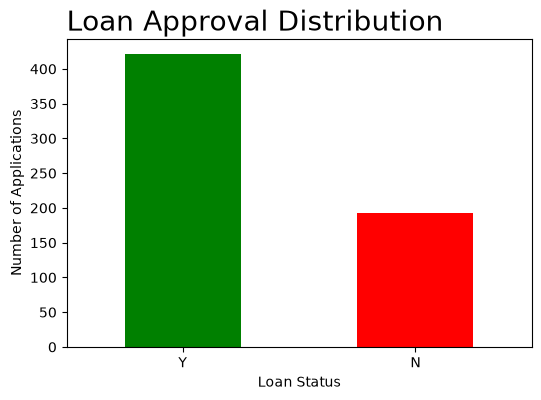

In [507]:
df['Loan_Status'].value_counts().plot(
    kind='bar',
    figsize=(6, 4), color = ['green', 'red']
)

plt.title('Loan Approval Distribution', loc = 'left', size =20)
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.show()

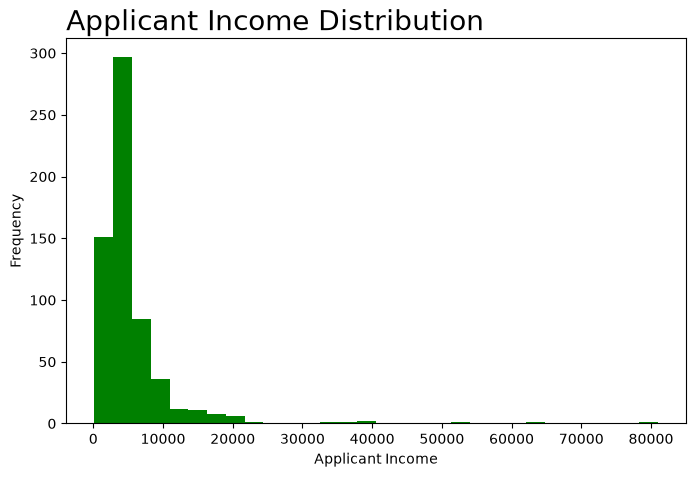

In [508]:
plt.figure(figsize=(8, 5))

plt.hist(df['ApplicantIncome'], bins=30, color = 'green')

plt.title('Applicant Income Distribution', loc = 'left', size = 20)
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')

plt.show()

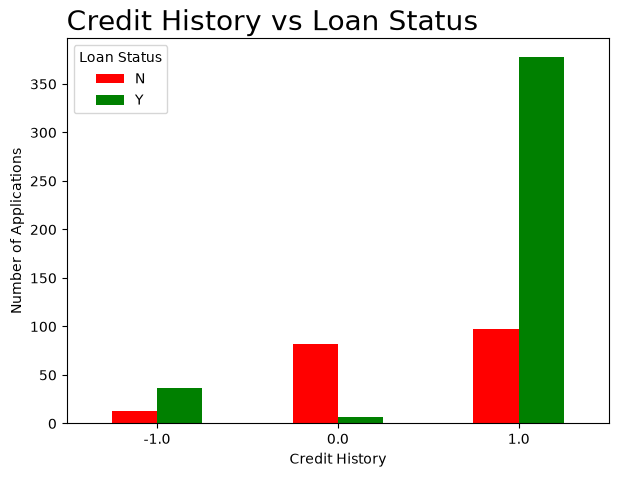

In [509]:
pd.crosstab(
    df['Credit_History'],
    df['Loan_Status']
).plot(
    kind='bar',
    figsize=(7, 5), color = ['red', 'green']
)

plt.title('Credit History vs Loan Status', size = 20, loc = 'left')
plt.xlabel('Credit History')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.show()

### 13.3 Education and Loan Approval

The relationship between an applicant's education level and loan approval is examined.

Approval rates are compared between graduate and non-graduate applicants to determine whether education level is associated with loan approval.

In [510]:
pd.crosstab(
    df['Education'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


In [511]:
pd.crosstab(
    df['Education'],
    df['Loan_Status']
)

Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


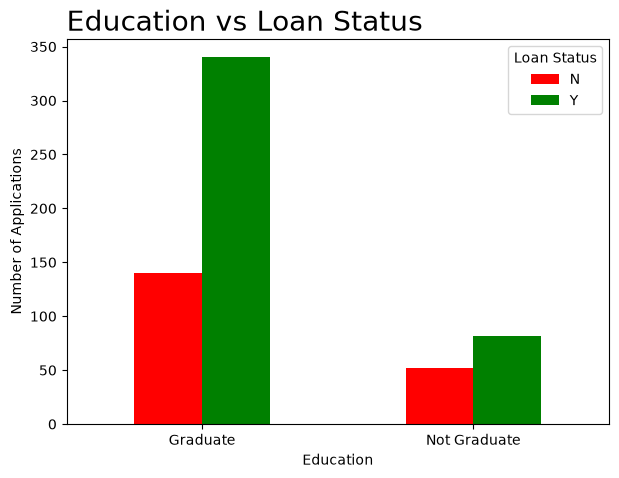

In [512]:
education_status = pd.crosstab(
    df['Education'],
    df['Loan_Status']
)

education_status.plot(
    kind='bar',
    figsize=(7, 5), color = ['red', 'green']
)

plt.title('Education vs Loan Status', loc = 'left', size = 20)
plt.xlabel('Education')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

### 13.4 Property Area and Loan Approval

The relationship between the applicant's property area and loan approval is examined.

Approval rates are compared across rural, semiurban, and urban property areas to determine whether property location is associated with loan approval.

In [513]:
pd.crosstab(
    df['Property_Area'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


In [514]:
pd.crosstab(
    df['Property_Area'],
    df['Loan_Status']
)

Loan_Status,N,Y
Property_Area,,
Rural,69,110
Semiurban,54,179
Urban,69,133


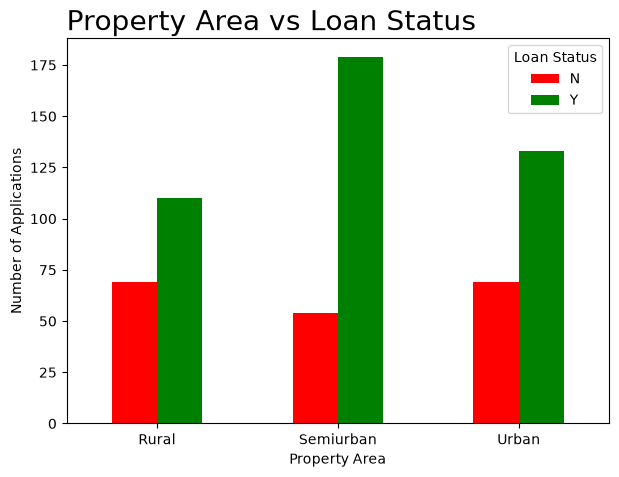

In [515]:
property_status = pd.crosstab(
    df['Property_Area'],
    df['Loan_Status']
)

property_status.plot(
    kind='bar',
    figsize=(7, 5), color = ['red', 'green']
)

plt.title('Property Area vs Loan Status', loc = 'left', size = 20)
plt.xlabel('Property Area')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

pd.crosstab(
    df['Education'],
    df['Loan_Status'],
    normalize='index'
) * 100

### Education and Loan Approval — Finding

Graduate applicants have a higher loan approval rate (70.83%) compared with non-graduate applicants (61.19%).

This represents a difference of approximately 9.64 percentage points. Although education appears to be associated with loan approval in the dataset, this relationship does not imply causation because other applicant characteristics may influence the loan decision.

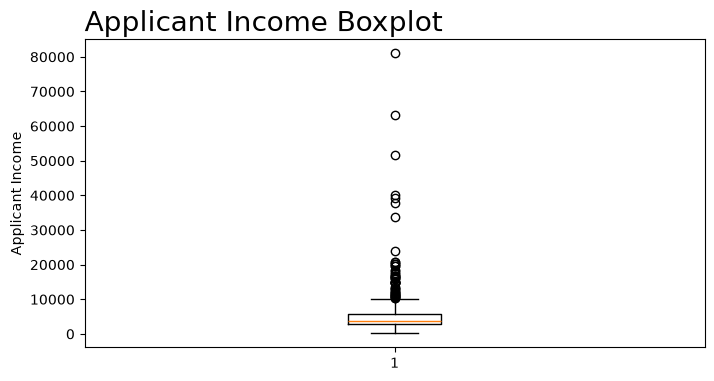

In [516]:
plt.figure(figsize=(8, 4))

plt.boxplot(df['ApplicantIncome'])

plt.title('Applicant Income Boxplot', loc = 'left', size = 20)
plt.ylabel('Applicant Income')

plt.show()

In [517]:
df.groupby('Loan_Status')['ApplicantIncome'].median()

Loan_Status
N    3833.5
Y    3812.5
Name: ApplicantIncome, dtype: float64

In [518]:
df.groupby('Loan_Status')['ApplicantIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,192.0,5446.078125,6819.558528,150.0,2885.0,3833.5,5861.25,81000.0
Y,422.0,5384.068720,5765.441615,210.0,2877.5,3812.5,5771.50,63337.0


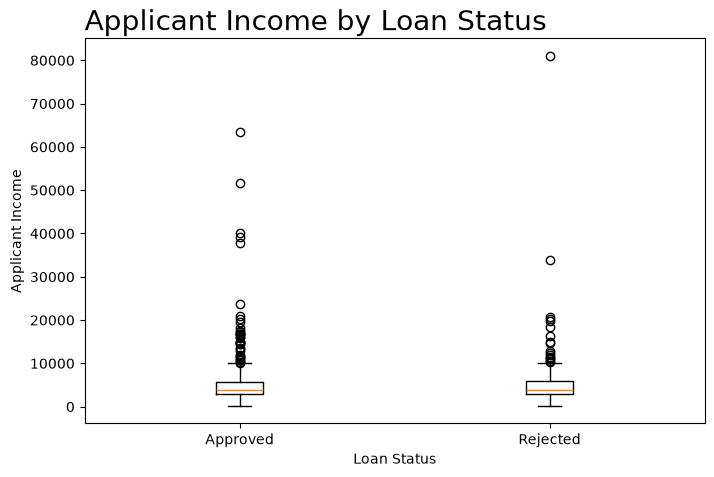

In [519]:
income_approved = df[df['Loan_Status'] == 'Y']['ApplicantIncome']
income_rejected = df[df['Loan_Status'] == 'N']['ApplicantIncome']

plt.figure(figsize=(8, 5))

plt.boxplot(
    [income_approved, income_rejected],
    tick_labels=['Approved', 'Rejected']
)

plt.title('Applicant Income by Loan Status', loc = 'left', size = 20)
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')

plt.show()

In [520]:
df.groupby('Loan_Status')['ApplicantIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,192.0,5446.078125,6819.558528,150.0,2885.0,3833.5,5861.25,81000.0
Y,422.0,5384.068720,5765.441615,210.0,2877.5,3812.5,5771.50,63337.0


In [521]:
df.groupby('Loan_Status')['ApplicantIncome'].median()

Loan_Status
N    3833.5
Y    3812.5
Name: ApplicantIncome, dtype: float64

In [522]:
df.groupby('Loan_Status')['ApplicantIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,192.0,5446.078125,6819.558528,150.0,2885.0,3833.5,5861.25,81000.0
Y,422.0,5384.068720,5765.441615,210.0,2877.5,3812.5,5771.50,63337.0


### Applicant Income and Loan Approval — Finding

Applicant income shows very similar central tendencies between approved and rejected loan applications.

The median applicant income is 3,833.5 for rejected applications and 3,812.5 for approved applications. The mean income is also similar between the two groups.

However, the income distribution is strongly right-skewed, with a maximum income of 81,000 compared with a median of approximately 3,813.

Rejected applications also show greater income variability than approved applications, as indicated by their higher standard deviation.

Overall, applicant income alone does not appear to strongly distinguish loan approval outcomes. However, its skewed distribution may warrant transformation during feature engineering.

### 13.6 Coapplicant Income Distribution

Coapplicant income is analyzed to understand its distribution, central tendency, variability, and potential extreme observations.

The variable is also compared across loan approval outcomes to determine whether coapplicant income is associated with loan approval.

In [523]:
df['CoapplicantIncome'].describe()

count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

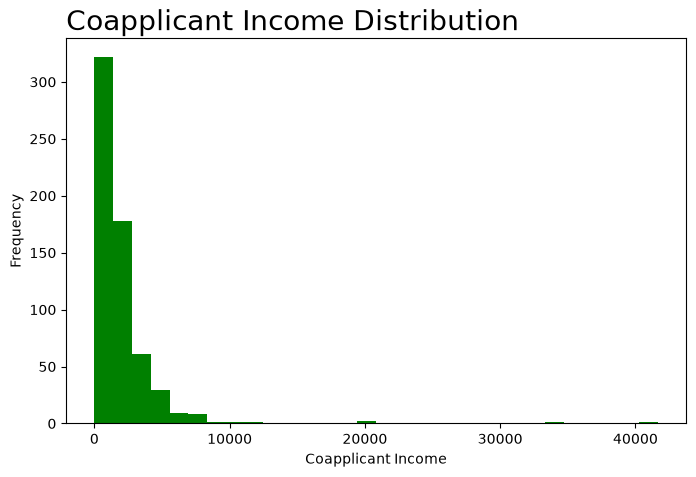

In [524]:
plt.figure(figsize=(8, 5))

plt.hist(df['CoapplicantIncome'], bins=30, color = 'green')

plt.title('Coapplicant Income Distribution', size = 20, loc = 'left')
plt.xlabel('Coapplicant Income')
plt.ylabel('Frequency')

plt.show()

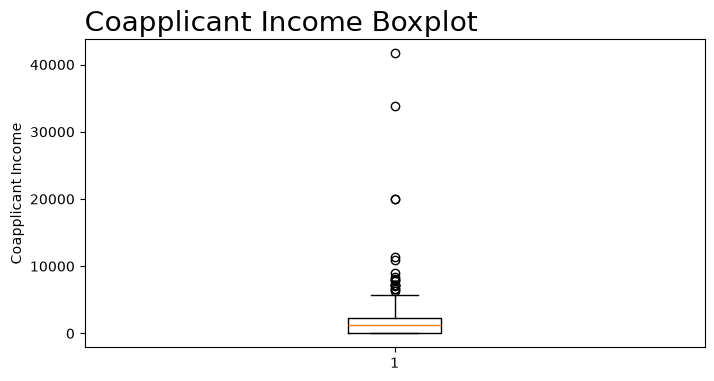

In [525]:
plt.figure(figsize=(8, 4))

plt.boxplot(df['CoapplicantIncome'])

plt.title('Coapplicant Income Boxplot', size = 20, loc = 'left')
plt.ylabel('Coapplicant Income')

plt.show()

In [526]:
df.groupby('Loan_Status')['CoapplicantIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,192.0,1877.807292,4384.060103,0.0,0.0,268.0,2273.75,41667.0
Y,422.0,1504.516398,1924.754855,0.0,0.0,1239.5,2297.25,20000.0


In [527]:
df.groupby('Loan_Status')['CoapplicantIncome'].median()

Loan_Status
N     268.0
Y    1239.5
Name: CoapplicantIncome, dtype: float64

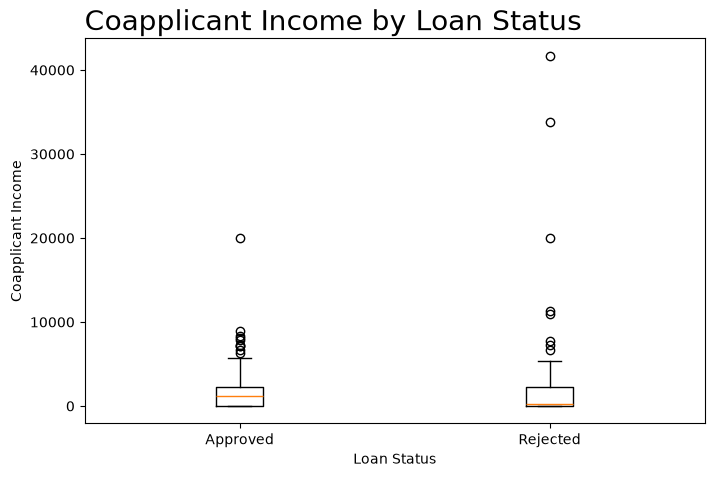

In [528]:
co_income_approved = df[df['Loan_Status'] == 'Y']['CoapplicantIncome']
co_income_rejected = df[df['Loan_Status'] == 'N']['CoapplicantIncome']

plt.figure(figsize=(8, 5))

plt.boxplot(
    [co_income_approved, co_income_rejected],
    tick_labels=['Approved', 'Rejected']
)

plt.title('Coapplicant Income by Loan Status', loc = 'left', size = 20)
plt.xlabel('Loan Status')
plt.ylabel('Coapplicant Income')

plt.show()

### Coapplicant Income and Loan Approval — Finding

Coapplicant income shows a substantial difference in median values between approved and rejected applications.

The median coapplicant income is 1,239.5 for approved applications compared with 268.0 for rejected applications.

The variable is strongly right-skewed, with a large number of applicants having zero coapplicant income and a small number of observations with very high incomes. This causes the mean to differ substantially from the median.

Extreme values are retained at this stage because they may represent legitimate applicants rather than data errors.

Coapplicant income appears to contain potentially useful information for predicting loan approval, although its predictive contribution will be evaluated alongside the other variables during model development.

### 13.7 Loan Amount Distribution

The distribution of loan amounts is examined to understand its central tendency, variability, skewness, and potential extreme observations.

Loan amount is also compared across loan approval outcomes to determine whether the requested loan amount is associated with loan approval.

Extreme values will be investigated rather than automatically removed, since they may represent legitimate loan applications.

In [529]:
df['LoanAmount'].describe()

count    614.000000
mean     145.752443
std       84.107233
min        9.000000
25%      100.250000
50%      128.000000
75%      164.750000
max      700.000000
Name: LoanAmount, dtype: float64

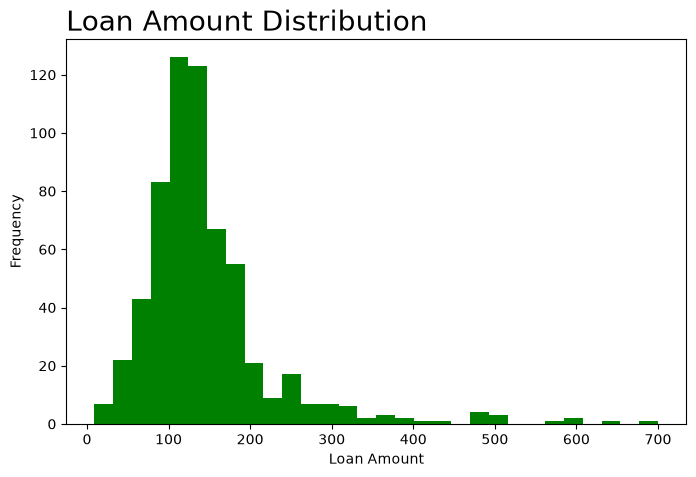

In [530]:
plt.figure(figsize=(8, 5))

plt.hist(df['LoanAmount'], bins=30, color = 'green')

plt.title('Loan Amount Distribution', loc = 'left', size = 20)
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

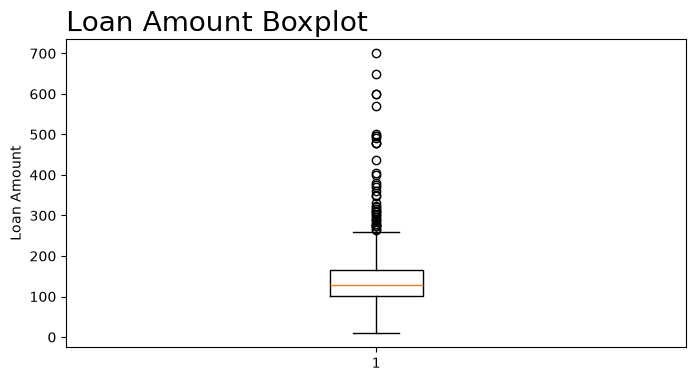

In [531]:
plt.figure(figsize=(8, 4))

plt.boxplot(df['LoanAmount'].dropna())

plt.title('Loan Amount Boxplot', loc = 'left', size = 20)
plt.ylabel('Loan Amount')

plt.show()

In [532]:
df.groupby('Loan_Status')['LoanAmount'].median()

Loan_Status
N    128.0
Y    128.0
Name: LoanAmount, dtype: float64

In [533]:
df.groupby('Loan_Status')['LoanAmount'].describe()

,count,mean,std,min,25%,50%,75%,max
Loan_Status,,,,,,,,
N,192.0,149.890625,83.529056,9.0,102.75,128.0,173.0,570.0
Y,422.0,143.869668,84.400468,17.0,100.00,128.0,160.0,700.0


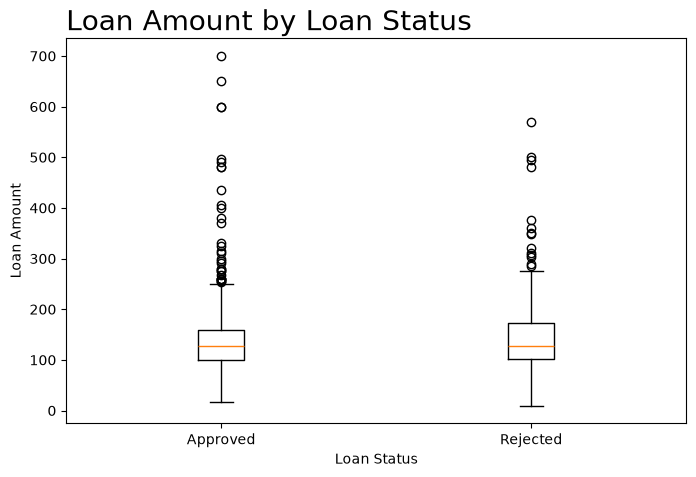

In [534]:
loan_approved = df[df['Loan_Status'] == 'Y']['LoanAmount']
loan_rejected = df[df['Loan_Status'] == 'N']['LoanAmount']

plt.figure(figsize=(8, 5))

plt.boxplot(
    [loan_approved, loan_rejected],
    tick_labels=['Approved', 'Rejected']
)

plt.title('Loan Amount by Loan Status', loc = 'left', size = 20)
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')

plt.show()

### Loan Amount and Loan Approval — Finding

The median loan amount is identical for approved and rejected applications at 128.

The mean loan amounts are also relatively similar, with 149.89 for rejected applications and 143.87 for approved applications.

Although the loan amount distribution contains extreme observations, these values have not been removed because they may represent legitimate loan applications.

Overall, loan amount alone does not appear to strongly distinguish approved from rejected applications based on the descriptive statistics. Its predictive contribution will therefore be evaluated together with the other applicant characteristics during model development.

### 13.8 Loan Amount Term and Loan Approval

The relationship between loan repayment term and loan approval is examined.

The distribution of loan terms is analyzed and approval rates are compared across the different repayment periods to determine whether loan term is associated with loan approval.

In [535]:
df['Loan_Amount_Term'].value_counts().sort_index()

Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    526
480.0     15
Name: count, dtype: int64

In [536]:
pd.crosstab(
    df['Loan_Amount_Term'],
    df['Loan_Status']
)

Loan_Status,N,Y
Loan_Amount_Term,,
12.0,0,1
36.0,2,0
60.0,0,2
84.0,1,3
120.0,0,3
180.0,15,29
240.0,1,3
300.0,5,8
360.0,159,367


In [537]:
pd.crosstab(
    df['Loan_Amount_Term'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Loan_Amount_Term,,
12.0,0.000000,100.000000
36.0,100.000000,0.000000
60.0,0.000000,100.000000
84.0,25.000000,75.000000
120.0,0.000000,100.000000
180.0,34.090909,65.909091
240.0,25.000000,75.000000
300.0,38.461538,61.538462
360.0,30.228137,69.771863


### Loan Amount Term and Loan Approval — Finding

Loan repayment terms are highly concentrated around 360 months, with 526 of the 614 applications having this term.

Among applicants with a 360-month loan term, 69.77% were approved and 30.23% were rejected.

Some less common loan-term categories show extreme approval rates, including 100% approval for 12-, 60-, and 120-month terms. However, these categories contain only 1–3 observations and therefore should not be interpreted as strong evidence of an association.

The 480-month category contains 15 observations and has a lower approval rate of 40%, but the sample size is still relatively small.

Overall, `Loan_Amount_Term` will be retained as a potential predictor, while rare categories will be treated cautiously during model development.

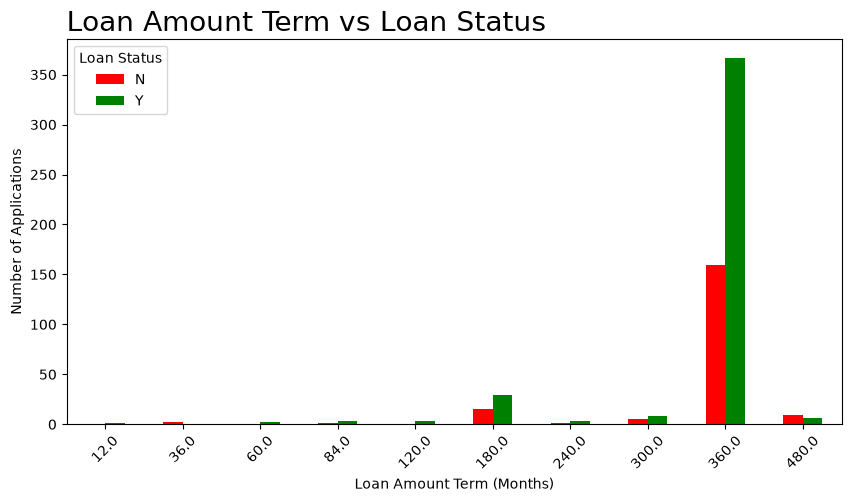

In [538]:
term_status = pd.crosstab(
    df['Loan_Amount_Term'],
    df['Loan_Status']
)

term_status.plot(
    kind='bar',
    figsize=(10, 5), color = ['red', 'green']
)

plt.title('Loan Amount Term vs Loan Status', loc = 'left', size = 20)
plt.xlabel('Loan Amount Term (Months)')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)
plt.legend(title='Loan Status')

plt.show()

In [539]:
pd.crosstab(
    df['Gender'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.876494,69.123506


In [540]:
pd.crosstab(
    df['Married'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.179551,71.820449


In [541]:
pd.crosstab(
    df['Dependents'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Dependents,,
0,31.388889,68.611111
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


In [542]:
pd.crosstab(
    df['Self_Employed'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Self_Employed,,
No,31.203008,68.796992
Yes,31.707317,68.292683


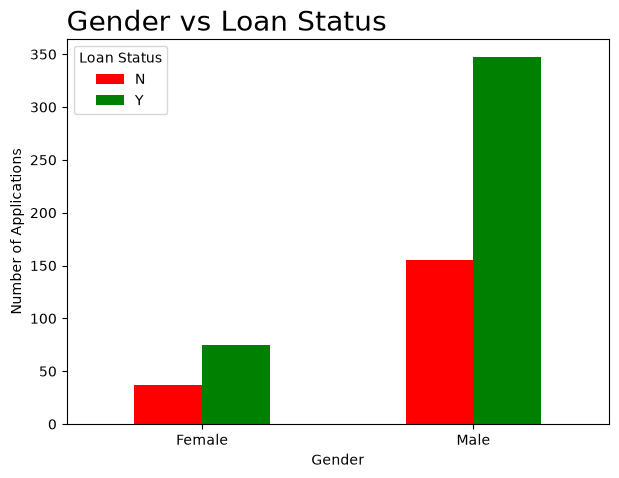

In [543]:
gender_status = pd.crosstab(df['Gender'], df['Loan_Status'])

gender_status.plot(
    kind='bar',
    figsize=(7, 5), color = ['red', 'green']
)

plt.title('Gender vs Loan Status', loc = 'left', size =20)
plt.xlabel('Gender')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

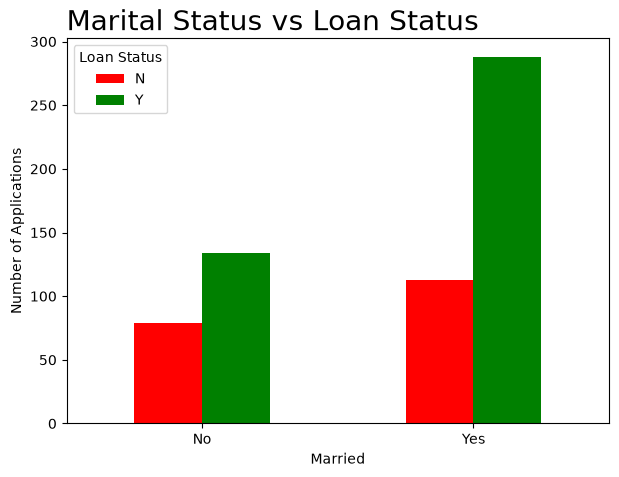

In [544]:
married_status = pd.crosstab(df['Married'], df['Loan_Status'])

married_status.plot(
    kind='bar',
    figsize=(7, 5), color = ['red', 'green']
)

plt.title('Marital Status vs Loan Status', loc = 'left', size = 20)
plt.xlabel('Married')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

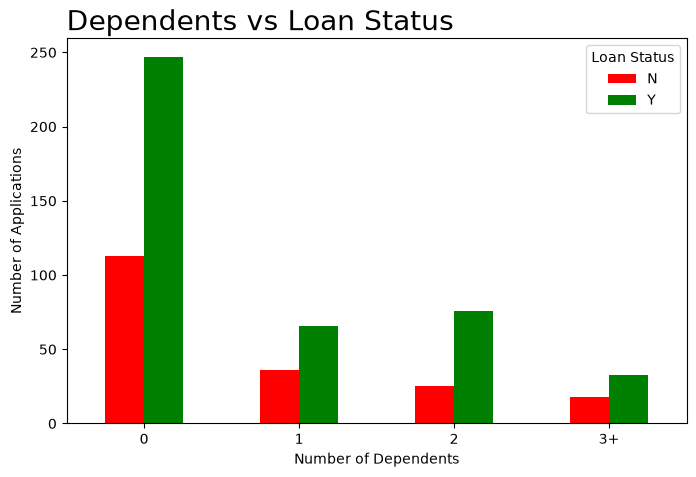

In [545]:
dependents_status = pd.crosstab(df['Dependents'], df['Loan_Status'])

dependents_status.plot(
    kind='bar',
    figsize=(8, 5),color = ['red', 'green']
)

plt.title('Dependents vs Loan Status', loc = 'left', size = 20)
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

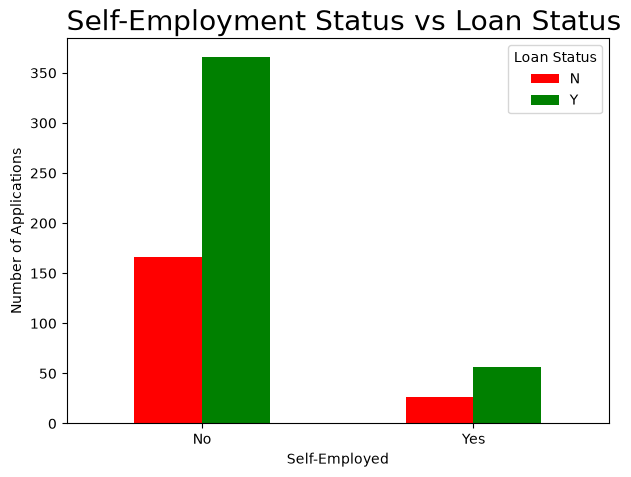

In [546]:
employment_status = pd.crosstab(df['Self_Employed'], df['Loan_Status'])

employment_status.plot(
    kind='bar',
    figsize=(7, 5), color = ['red', 'green']
)

plt.title('Self-Employment Status vs Loan Status', loc = 'left', size = 20)
plt.xlabel('Self-Employed')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

### Categorical Features and Loan Approval

The categorical variables Gender, Married, Dependents, and Self-Employed are compared with loan approval status.

Approval rates are calculated within each category to identify potential differences in loan approval outcomes. Bar charts are also used to visually compare approved and rejected applications across the categories.

The analysis helps identify categorical variables that may contain useful predictive information for the machine learning models.

### Categorical Features and Loan Approval — Findings

#### Gender
Loan approval rates are similar for female and male applicants, with approval rates of 66.96% and 69.12%, respectively. This suggests that Gender does not have a strong association with loan approval in the dataset.

#### Married
Married applicants have a higher approval rate (71.82%) compared with applicants who are not married (62.91%). This represents a difference of approximately 8.91 percentage points.

#### Dependents
Approval rates vary across dependent categories. Applicants with two dependents have the highest approval rate (75.25%), while applicants with one or three or more dependents have lower approval rates (64.71%). These differences should be interpreted cautiously because category sizes differ.

#### Self-Employed
Approval rates are almost identical for self-employed (68.29%) and non-self-employed applicants (68.80%). Therefore, Self_Employed does not appear to have a strong association with loan approval based on descriptive analysis alone.

### 3.13 Credit History, Applicant Income and Loan Approval

Credit history and applicant income are examined together to determine whether income shows different patterns across credit-history groups and loan approval outcomes.

This multivariable analysis helps identify interactions between important predictors before proceeding to feature engineering and machine learning.

In [547]:
pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,N,Y
Credit_History,,
-1.0,26.000000,74.000000
0.0,92.134831,7.865169
1.0,20.421053,79.578947


In [548]:
df.groupby('Credit_History')['ApplicantIncome'].describe()

,count,mean,std,min,25%,50%,75%,max
Credit_History,,,,,,,,
-1.0,50.0,4693.080000,3799.240605,416.0,2675.0,3644.0,5746.0,20833.0
0.0,89.0,5679.438202,9301.896041,1500.0,2787.0,3547.0,5285.0,81000.0
1.0,475.0,5426.526316,5535.393384,150.0,2908.5,3859.0,5820.0,63337.0


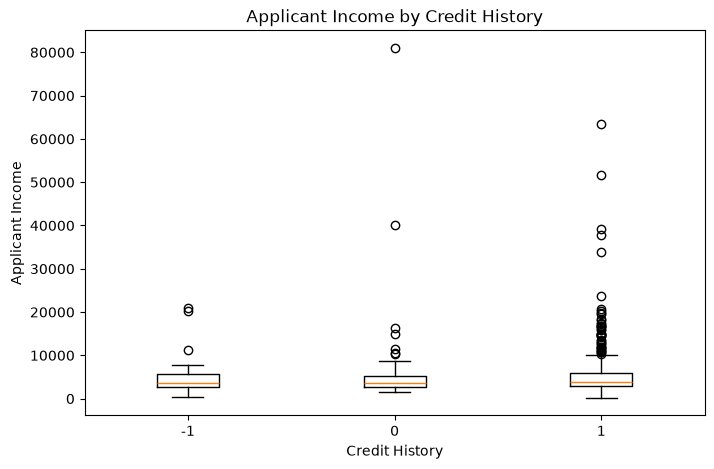

In [549]:
credit_income = []

for credit in sorted(df['Credit_History'].unique()):
    credit_income.append(
        df[df['Credit_History'] == credit]['ApplicantIncome']
    )

plt.figure(figsize=(8, 5))

plt.boxplot(
    credit_income,
    tick_labels=[str(int(x)) for x in sorted(df['Credit_History'].unique())]
)

plt.title('Applicant Income by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Applicant Income')

plt.show()

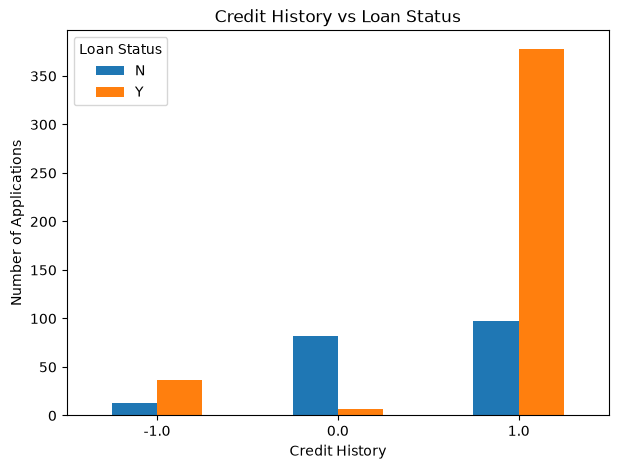

In [550]:
credit_status = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status']
)

credit_status.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Credit History vs Loan Status')
plt.xlabel('Credit History')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

In [551]:
credit_approval = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status'],
    normalize='index'
) * 100

credit_approval

Loan_Status,N,Y
Credit_History,,
-1.0,26.000000,74.000000
0.0,92.134831,7.865169
1.0,20.421053,79.578947


### Credit History, Applicant Income and Loan Approval — Finding

Credit history shows a very strong association with loan approval.

Applicants with a positive credit history (Credit_History = 1) have an approval rate of 79.58%, while applicants with a negative credit history (Credit_History = 0) have an approval rate of only 7.87%.

Applicants with originally missing credit-history values, represented by -1 after imputation, have an approval rate of 74.00%.

In comparison, median applicant income is relatively similar across credit-history groups, ranging from 3,547 to 3,859 for the groups with known credit history.

This suggests that credit history is considerably more strongly associated with loan approval than applicant income in this dataset. Credit_History is therefore expected to be an important predictor during machine-learning model development.

In [552]:
df['TotalIncome'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

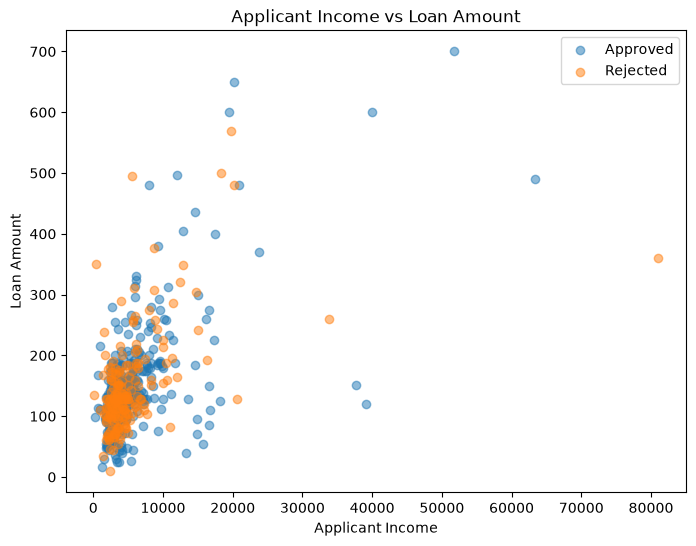

In [553]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df['Loan_Status'] == 'Y']['ApplicantIncome'],
    df[df['Loan_Status'] == 'Y']['LoanAmount'],
    alpha=0.5,
    label='Approved'
)

plt.scatter(
    df[df['Loan_Status'] == 'N']['ApplicantIncome'],
    df[df['Loan_Status'] == 'N']['LoanAmount'],
    alpha=0.5,
    label='Rejected'
)

plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend()

plt.show()

### 3.14 Applicant Income and Loan Amount

Applicant income and loan amount are examined together to determine whether higher-income applicants tend to request larger loans and whether this relationship differs between approved and rejected applications.

A scatter plot is used to visualize the relationship between income and requested loan amount while distinguishing loan approval outcomes.

### Applicant Income and Loan Amount — Finding

The scatter plot shows that most loan applications are concentrated within relatively low applicant-income and loan-amount ranges.

There appears to be a positive relationship between Applicant Income and Loan Amount, as applicants with higher incomes generally tend to request larger loans.

However, approved and rejected applications show substantial overlap across the distribution. This indicates that Applicant Income and Loan Amount alone do not clearly distinguish between approved and rejected applications.

Several extreme observations are also visible, including applicants with very high incomes and loan amounts. These observations will be investigated during feature engineering and data preparation rather than being automatically removed.

The analysis further supports the earlier finding that other variables, particularly Credit_History, may have stronger predictive value for loan approval.

In [554]:
pd.crosstab(
    [df['Education'], df['Property_Area']],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status                         N          Y
Education    Property_Area                      
Graduate     Rural          35.877863  64.122137
             Semiurban      22.994652  77.005348
             Urban          30.864198  69.135802
Not Graduate Rural          45.833333  54.166667
             Semiurban      23.913043  76.086957
             Urban          47.500000  52.500000

### Education, Property Area and Loan Approval — Finding

Education and Property Area were examined together to identify potential interaction effects.

Semiurban applicants had the highest approval rates for both graduates (77.01%) and non-graduates (76.09%), suggesting that the relatively high approval rate associated with Semiurban properties is not limited to graduates.

The largest education-related difference was observed among Urban applicants, where graduates had an approval rate of 69.14% compared with 52.50% for non-graduates.

Among Rural applicants, graduates also had a higher approval rate (64.12%) than non-graduates (54.17%).

These results suggest that Education and Property Area may contain interacting information relevant to loan approval. However, the observed differences are descriptive associations and do not establish causation.

### 3.16 Correlation Analysis

Correlation analysis is performed to examine the strength and direction of relationships between the numerical variables in the dataset.

The analysis focuses on ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, and Credit_History.

Correlation values range from -1 to +1:

- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate a weak or no linear relationship.

Correlation does not imply causation. The results are used to understand relationships between variables and identify potential multicollinearity before machine learning.

In [555]:
numeric_cols = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,0.020225
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,-0.086654
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.046710
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,0.005924
Credit_History,0.020225,-0.086654,-0.046710,0.005924,1.000000


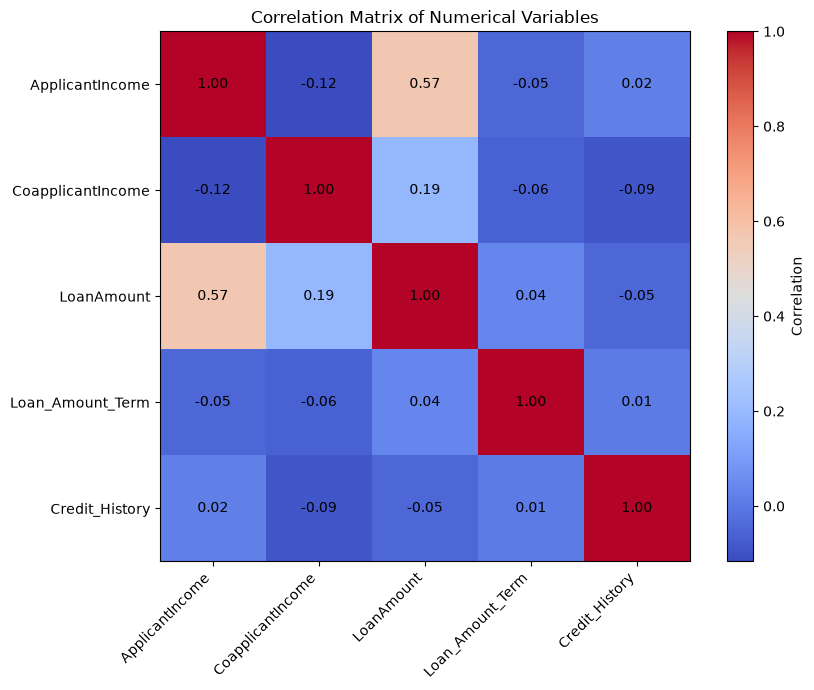

In [556]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    interpolation='none'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix of Numerical Variables')

# Add correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

In [557]:
df['Loan_Status_Num'] = df['Loan_Status'].map({
    'N': 0,
    'Y': 1
})

In [558]:
correlation_with_target = df[
    numeric_cols + ['Loan_Status_Num']
].corr()['Loan_Status_Num'].sort_values(ascending=False)

correlation_with_target

Loan_Status_Num      1.000000
Credit_History       0.280181
ApplicantIncome     -0.004710
Loan_Amount_Term    -0.022549
LoanAmount          -0.033214
CoapplicantIncome   -0.059187
Name: Loan_Status_Num, dtype: float64

In [559]:
df.drop('Loan_Status_Num', axis=1, inplace=True)

### 3.17 EDA Summary

The exploratory data analysis examined the distributions of numerical and categorical variables and their relationships with loan approval status.

Key relationships identified during the analysis included:

- Credit History showed a strong association with loan approval.
- Education and Property Area showed differences in approval rates across their categories.
- Married applicants had a higher approval rate than non-married applicants.
- Gender and Self-Employment showed relatively small differences in approval rates.
- Applicant Income and Coapplicant Income showed substantial variation and the presence of extreme observations.
- Loan Amount showed similar median values between approved and rejected applications.
- Loan Amount Term was highly concentrated around 360 months.
- Applicant Income and Loan Amount showed a positive relationship, although approved and rejected applications substantially overlapped.
- Education and Property Area showed some evidence of interaction in their relationship with loan approval.
- Correlation analysis was performed to assess relationships among the numerical variables and identify potential multicollinearity.

The findings from EDA will guide the feature engineering and machine-learning stages of the project.

In [560]:
correlation_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.565181,-0.046531,0.020225
CoapplicantIncome,-0.116605,1.000000,0.189218,-0.059383,-0.086654
LoanAmount,0.565181,0.189218,1.000000,0.036960,-0.046710
Loan_Amount_Term,-0.046531,-0.059383,0.036960,1.000000,0.005924
Credit_History,0.020225,-0.086654,-0.046710,0.005924,1.000000


In [561]:
correlation_with_target

Loan_Status_Num      1.000000
Credit_History       0.280181
ApplicantIncome     -0.004710
Loan_Amount_Term    -0.022549
LoanAmount          -0.033214
CoapplicantIncome   -0.059187
Name: Loan_Status_Num, dtype: float64

### 4.1 Feature Engineering

Feature engineering involves creating, transforming, or restructuring variables to provide the machine-learning model with more meaningful information.

For the Loan Prediction dataset, the feature engineering process will focus on creating features that better represent the applicant's financial capacity and loan burden.

The following transformations will be considered:

* **Total Income:** Combining `ApplicantIncome` and `CoapplicantIncome` to represent the total household income available for loan repayment.
* **Loan-to-Income Ratio:** Comparing the `LoanAmount` with `TotalIncome` to measure the size of the requested loan relative to the applicant's income.
* **Log Transformation:** Applying logarithmic transformations to highly skewed financial variables such as income and loan amount to reduce the influence of extreme observations.
* **Dependents Conversion:** Converting the `3+` category in `Dependents` into a numerical value so that the variable can be used appropriately by machine-learning algorithms.
* **Loan Term Conversion:** Converting `Loan_Amount_Term` from months into years to create a more interpretable feature.

These engineered features will be evaluated to determine whether they provide useful information for predicting loan approval.

The transformations will be performed carefully to avoid unnecessary variables, duplication, or data leakage before the machine-learning stage.


### 4.2 Create Total Income

The `ApplicantIncome` and `CoapplicantIncome` variables represent the individual incomes associated with each loan application. Since both incomes can contribute to the applicant's overall ability to repay the loan, they can be combined into a single feature.

A new variable, **TotalIncome**, will therefore be created by adding the applicant's income and coapplicant's income.

The formula is:

**TotalIncome = ApplicantIncome + CoapplicantIncome**

This feature provides a more complete representation of the household's financial capacity and may help the machine-learning model identify relationships that are not as apparent when the two income variables are considered separately.


In [562]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

### 4.4 Create Loan-to-Income Ratio

The **Loan-to-Income Ratio** measures the size of the requested loan relative to the applicant's total income.

It will be calculated using the `LoanAmount` and the newly created `TotalIncome` features.

The formula is:

**LoanIncomeRatio = LoanAmount / TotalIncome**

This feature can help indicate the applicant's potential loan burden. A higher ratio means that the requested loan is relatively large compared with the applicant's total income, while a lower ratio indicates that the loan amount is smaller relative to the applicant's income.

The `LoanIncomeRatio` feature may provide the machine-learning model with additional information about the applicant's ability to manage the requested loan.


In [563]:
df['LoanIncomeRatio'] = df['LoanAmount'] / df['TotalIncome']

### 4.5 Create Total Income Log

Income variables often contain extreme values and are usually positively skewed. Applicants with very high incomes can influence the distribution and affect the performance of some machine-learning algorithms.

To reduce the effect of these extreme values, a logarithmic transformation will be applied to the `TotalIncome` feature, creating a new variable called **TotalIncomeLog**.

The transformation is expressed as:

**TotalIncomeLog = log(1 + TotalIncome)**

The addition of 1 ensures that the logarithm can be calculated even when the income value is zero.

This transformation helps normalize the distribution of income values, reduce skewness, and improve the ability of machine-learning models to learn patterns from the data.

---

### 4.6 Create Loan Amount Log

The `LoanAmount` variable may also contain extreme values and exhibit a positively skewed distribution.

To reduce the impact of these extreme observations, a logarithmic transformation will be applied to create a new feature called **LoanAmountLog**.

The transformation is expressed as:

**LoanAmountLog = log(1 + LoanAmount)**

This transformation reduces skewness, minimizes the influence of outliers, and creates a more balanced distribution of loan amounts.

The log-transformed variables may improve model performance, particularly for algorithms that are sensitive to non-normal data distributions.


In [564]:
df['TotalIncomeLog'] = np.log1p(df['TotalIncome'])
df['LoanAmountLog'] = np.log1p(df['LoanAmount'])

### 4.7 Convert Dependents to Numerical Format

The `Dependents` variable contains categorical values representing the number of dependents an applicant has. One of the categories is recorded as **`3+`**, which cannot be directly treated as a numerical value.

To make the variable suitable for machine-learning algorithms, the `3+` category will be converted to **3** and the entire `Dependents` column will then be converted to an integer data type.

This transformation allows the number of dependents to be treated as a numerical feature while preserving the information contained in the original variable.

The transformation will be:

**`3+` → `3`**

After the conversion, the `Dependents` variable will contain numerical values representing the number of dependents.


In [565]:
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = df['Dependents'].astype(int)

### 4.8 Create Loan Term in Years

The `Loan_Amount_Term` variable represents the duration of the loan in **months**. To make this variable easier to interpret, it will be converted from months to years.

A new feature called **LoanTermYears** will be created using the following formula:

**LoanTermYears = Loan_Amount_Term / 12**

For example, a loan term of **360 months** will be converted to **30 years**.

This transformation provides a more intuitive representation of the loan duration while retaining the same underlying information. The original `Loan_Amount_Term` variable can be retained for comparison during the feature selection stage.


In [566]:
df['LoanTermYears'] = df['Loan_Amount_Term'] / 12

In [567]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
 13  TotalIncome        614 non-null    float64
 14  LoanIncomeRatio    614 non-null    float64
 15  TotalIncomeLog     614 non-null    float64
 16  LoanAmountLog      614 non-null    fl

In [568]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,TotalIncomeLog,LoanAmountLog,LoanTermYears
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021884,8.674197,4.859812,30.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021015,8.714732,4.859812,30.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.022000,8.006701,4.204693,30.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024287,8.505525,4.795791,30.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023500,8.699681,4.955827,30.0


In [569]:
df.to_csv('loan_prediction_cleaned.csv', index=False)

### 6.2 Feature Selection

Feature selection involves identifying the variables that will be used as predictors in the machine-learning model while excluding variables that are irrelevant, redundant, or likely to introduce unnecessary complexity.

The target variable for the model is `Loan_Status`, which represents whether a loan application was approved or rejected.

The following variables will be excluded from the predictors:

* **`Loan_ID`** will be excluded because it is an identification number and does not provide meaningful predictive information.
* **`ApplicantIncome`** and **`CoapplicantIncome`** will not be used directly because their combined information is represented through the engineered income features.
* **`TotalIncome`** will be excluded in favor of `TotalIncomeLog`, which reduces the effect of extreme income values.
* **`LoanAmount`** will be excluded in favor of `LoanAmountLog`.
* **`Loan_Amount_Term`** will be excluded in favor of `LoanTermYears`.

The selected predictor variables are:

* `Gender`
* `Married`
* `Dependents`
* `Education`
* `Self_Employed`
* `TotalIncomeLog`
* `LoanIncomeRatio`
* `LoanAmountLog`
* `LoanTermYears`
* `Credit_History`
* `Property_Area`

The target variable is:

* `Loan_Status`

This selection provides the model with demographic, financial, credit-history, and loan-related information while reducing unnecessary duplication among derived features.


In [570]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status',
 'TotalIncome',
 'LoanIncomeRatio',
 'TotalIncomeLog',
 'LoanAmountLog',
 'LoanTermYears']

In [571]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents             int64
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
TotalIncome          float64
LoanIncomeRatio      float64
TotalIncomeLog       float64
LoanAmountLog        float64
LoanTermYears        float64
dtype: object

In [572]:
X = df[
    [
        'Gender',
        'Married',
        'Dependents',
        'Education',
        'Self_Employed',
        'TotalIncomeLog',
        'LoanIncomeRatio',
        'LoanAmountLog',
        'LoanTermYears',
        'Credit_History',
        'Property_Area'
    ]
]

y = df['Loan_Status']

In [573]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 11)
y shape: (614,)


In [574]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,TotalIncomeLog,LoanIncomeRatio,LoanAmountLog,LoanTermYears,Credit_History,Property_Area
0,Male,No,0,Graduate,No,8.674197,0.021884,4.859812,30.0,1.0,Urban
1,Male,Yes,1,Graduate,No,8.714732,0.021015,4.859812,30.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,8.006701,0.022000,4.204693,30.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,8.505525,0.024287,4.795791,30.0,1.0,Urban
4,Male,No,0,Graduate,No,8.699681,0.023500,4.955827,30.0,1.0,Urban


In [575]:
y.head()

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: str

### 6.4 Encoding Categorical Variables

Machine-learning algorithms require categorical variables to be represented in a numerical format. The selected dataset contains several categorical variables, including `Gender`, `Married`, `Education`, `Self_Employed`, and `Property_Area`.

These variables will be transformed into numerical representations using **one-hot encoding**. This approach creates separate binary columns for the different categories without introducing an artificial ranking between them.

The `drop_first=True` parameter will be used to remove one category from each categorical variable and reduce redundant information caused by perfect multicollinearity.

The following categorical variables will be encoded:

* `Gender`
* `Married`
* `Education`
* `Self_Employed`
* `Property_Area`

The numerical variables, including `Dependents`, `TotalIncomeLog`, `LoanIncomeRatio`, `LoanAmountLog`, `LoanTermYears`, and `Credit_History`, will remain in their numerical form.

After encoding, all predictor variables will be numerical and ready for the model-training stage.


In [576]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        'Gender',
        'Married',
        'Education',
        'Self_Employed',
        'Property_Area'
    ],
    drop_first=True,
    dtype=int
)

In [577]:
X_encoded.head()

,Dependents,TotalIncomeLog,LoanIncomeRatio,LoanAmountLog,LoanTermYears,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,8.674197,0.021884,4.859812,30.0,1.0,1,0,0,0,0,1
1,1,8.714732,0.021015,4.859812,30.0,1.0,1,1,0,0,0,0
2,0,8.006701,0.022000,4.204693,30.0,1.0,1,1,0,1,0,1
3,0,8.505525,0.024287,4.795791,30.0,1.0,1,1,1,0,0,1
4,0,8.699681,0.023500,4.955827,30.0,1.0,1,0,0,0,0,1


In [578]:
X_encoded.dtypes

Dependents                   int64
TotalIncomeLog             float64
LoanIncomeRatio            float64
LoanAmountLog              float64
LoanTermYears              float64
Credit_History             float64
Gender_Male                  int64
Married_Yes                  int64
Education_Not Graduate       int64
Self_Employed_Yes            int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
dtype: object

In [579]:
print("Encoded X shape:", X_encoded.shape)

Encoded X shape: (614, 12)


In [580]:
y_encoded = y.map({
    'Y': 1,
    'N': 0
})

In [581]:
y_encoded.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

In [582]:
y_encoded.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

### 6.6 Train-Test Split

Before developing the machine-learning model, the dataset will be divided into separate training and testing datasets.

The **training dataset** will be used to train the model and allow it to learn patterns between the predictor variables and loan approval status.

The **testing dataset** will be kept separate during training and will be used later to evaluate how well the model performs on unseen data.

An **80:20 split** will be used, where approximately 80% of the observations will be allocated to the training set and 20% to the testing set.

A `random_state` of **42** will be used to ensure that the split is reproducible. **Stratification** will also be applied using the target variable so that the proportion of approved and rejected applications remains approximately consistent across both datasets.

This process helps provide a more reliable evaluation of the model's ability to generalize to new loan applications.


In [583]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [584]:
scaler = StandardScaler()

In [585]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [586]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (491, 12)
X_test_scaled: (123, 12)


In [587]:
scaler.fit_transform(X_train)

array([[-0.74858624, -1.08710329, -1.0172082 , ..., -0.39407375,
        -0.77417604,  1.42508393],
       [ 0.25020681, -1.0528974 ,  0.66462338, ..., -0.39407375,
         1.29169589, -0.70171306],
       [ 1.24899986, -0.27760827,  0.75663514, ..., -0.39407375,
        -0.77417604, -0.70171306],
       ...,
       [-0.74858624, -0.27687894,  0.06946539, ..., -0.39407375,
         1.29169589, -0.70171306],
       [-0.74858624, -0.37650717,  0.62328528, ..., -0.39407375,
         1.29169589, -0.70171306],
       [-0.74858624, -1.28152332,  2.57485409, ..., -0.39407375,
         1.29169589, -0.70171306]], shape=(491, 12))

In [588]:
scaler.transform(X_test)

array([[-0.74858624,  0.12302765, -0.59245807, ..., -0.39407375,
        -0.77417604, -0.70171306],
       [-0.74858624,  0.18336058,  0.55341682, ..., -0.39407375,
         1.29169589, -0.70171306],
       [-0.74858624,  0.97403551, -0.6830158 , ...,  2.53759609,
        -0.77417604, -0.70171306],
       ...,
       [ 2.24779292, -0.10703213,  0.61025716, ..., -0.39407375,
         1.29169589, -0.70171306],
       [-0.74858624,  0.88792668, -0.4849606 , ..., -0.39407375,
        -0.77417604, -0.70171306],
       [ 0.25020681, -0.27797305, -0.19830742, ..., -0.39407375,
        -0.77417604,  1.42508393]], shape=(123, 12))

In [589]:
X_train_scaled[:5]

array([[-0.74858624, -1.08710329, -1.0172082 , -1.89643886,  0.28069139,
         0.49919032,  0.46405445, -1.38033526, -0.54046763, -0.39407375,
        -0.77417604,  1.42508393],
       [ 0.25020681, -1.0528974 ,  0.66462338, -0.59627297,  0.28069139,
         0.49919032,  0.46405445,  0.72446168, -0.54046763, -0.39407375,
         1.29169589, -0.70171306],
       [ 1.24899986, -0.27760827,  0.75663514,  0.29877455,  0.28069139,
        -1.10278645,  0.46405445,  0.72446168, -0.54046763, -0.39407375,
        -0.77417604, -0.70171306],
       [ 0.25020681, -0.63780445,  0.44810522, -0.26968207, -2.48676788,
        -1.10278645,  0.46405445,  0.72446168,  1.85024956, -0.39407375,
        -0.77417604, -0.70171306],
       [-0.74858624, -0.35470004,  0.91370927,  0.29877455,  0.28069139,
         0.49919032,  0.46405445,  0.72446168, -0.54046763, -0.39407375,
         1.29169589, -0.70171306]])

### Model Selection and Training

With the data prepared, encoded, and scaled, we can now begin developing the machine-learning models.

Since the target variable Loan_Status contains two possible outcomes — approved (1) and rejected (0) — this is a binary classification problem.

Rather than relying on a single algorithm, multiple classification models will be developed and compared later. This will help determine which model provides the most suitable performance for predicting loan approval.

The first model will be Logistic Regression, which will serve as the baseline model.

Logistic Regression is appropriate for this problem because:

The target variable is binary.
It is suitable for classification problems.
It can estimate the probability of loan approval.
It is relatively simple and interpretable.
Its performance provides a useful baseline for comparison with more complex models.

For Logistic Regression, the scaled training data will be used because the model can be sensitive to differences in feature magnitude.

### Train Logistic Regression

import the Logistic Regression algorithm

In [590]:
log_reg = LogisticRegression(random_state=42)

In [591]:
log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Generate Predictions

After the model has been trained, predictions can be generated using the test data

In [592]:
y_pred_log = log_reg.predict(X_test_scaled)

In [593]:
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

### Decision Tree Classifier

Firstly train a Decision Tree model.

In [594]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

### Random Forest Classifier

The Random Forest Classifier will be developed as the next machine-learning model.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce a more robust prediction. Instead of relying on a single decision tree, the algorithm builds several trees using different samples and features and combines their predictions.

Random Forest is suitable for this loan prediction problem because it can:

Capture non-linear relationships between variables.
Handle interactions between different features.
Reduce the risk of overfitting compared with a single decision tree.
Provide feature importance information that can be useful during model interpretation.

Because Random Forest is a tree-based algorithm, feature scaling is not required. Therefore, the original X_train and X_test datasets will be used.

In [595]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

### K-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) algorithm will be developed as another classification model.

KNN predicts the class of a new observation by examining the closest observations in the training dataset. It then assigns the class that is most common among those neighboring observations.

KNN is useful for this project because it provides a different approach from the tree-based models and Logistic Regression. It can identify patterns based on the similarity between loan applicants.

Because KNN is sensitive to the scale of numerical variables, the scaled training and testing datasets will be used.

In [596]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

### Support Vector Machine (SVM)

The Support Vector Machine (SVM) algorithm will be developed as another classification model for predicting loan approval.

SVM attempts to identify an optimal decision boundary that separates the two loan-status classes:

1 → Approved
0 → Rejected

SVM can be useful when the relationship between the predictor variables and the target variable is complex and cannot be adequately represented by a simple linear boundary.

Because SVM is sensitive to differences in feature scale, the scaled training and testing datasets will be used.

The probability=True parameter will also be enabled so that the model can generate probability estimates for its predictions. These probabilities will be useful later when interpreting model predictions.

In [597]:
svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

### Evaluate Logistic Regression

The Logistic Regression model will be evaluated using the test dataset that was kept separate from the model-training process.

The evaluation will measure five key performance metrics:

Accuracy — the percentage of all predictions that were correct.
Precision — the proportion of applications predicted as approved that were actually approved.
Recall — the proportion of actually approved applications that the model correctly identified.
F1-score — the balance between precision and recall.
ROC-AUC — the model's ability to distinguish between approved and rejected applications across different classification thresholds

In [598]:
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(accuracy_log, 4))
print("Precision:", round(precision_log, 4))
print("Recall   :", round(recall_log, 4))
print("F1-Score :", round(f1_log, 4))
print("ROC-AUC  :", round(roc_auc_log, 4))

Logistic Regression
-------------------
Accuracy : 0.6748
Precision: 0.7064
Recall   : 0.9059
F1-Score : 0.7938
ROC-AUC  : 0.7598


In [599]:
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

### Evaluate Decision

The Decision Tree model will now be evaluated using the same metrics used for Logistic Regression. Using the same evaluation criteria ensures that the models can be compared fairly.

Unlike Logistic Regression, the Decision Tree was trained using the unscaled features, since tree-based algorithms generally do not require feature scaling.

First, generate the probability predictions needed for ROC-AUC:

In [600]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree")
print("-------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1-Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(roc_auc_tree, 4))

Decision Tree
-------------
Accuracy : 0.6911
Precision: 0.8052
Recall   : 0.7294
F1-Score : 0.7654
ROC-AUC  : 0.6673


### Random Forest Evaluation

The Random Forest model will now be evaluated using the same performance metrics used for Logistic Regression and Decision Tree.

Random Forest combines multiple decision trees, which can help reduce the limitations of using a single decision tree and potentially improve the model's ability to generalize to unseen loan applications.

Because Random Forest is a tree-based algorithm, it was trained using the unscaled features.

In [601]:
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [602]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

Random Forest
------------------
Accuracy : 0.8293
Precision: 0.8721
Recall   : 0.8824
F1-Score : 0.8772
ROC-AUC  : 0.8368


### The KNN model will now be evaluated using the same metrics.

Because KNN is sensitive to feature scaling, we used the scaled test data when generating its predictions.The KNN model will now be evaluated using the same metrics.

Because KNN is sensitive to feature scaling, we used the scaled test data when generating its predictions.

In [603]:
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [604]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

print("K-Nearest Neighbors")
print("-------------------")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1-Score :", round(f1_knn, 4))
print("ROC-AUC  :", round(roc_auc_knn, 4))

K-Nearest Neighbors
-------------------
Accuracy : 0.7073
Precision: 0.7475
Recall   : 0.8706
F1-Score : 0.8043
ROC-AUC  : 0.6861


### Support Vector Machine (SVM) Evaluation

The SVM model will now be evaluated using the same metrics as the previous models.

Because SVM is sensitive to feature scale, we will use the scaled test data.

In [605]:
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

In [606]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Support Vector Machine")
print("-----------------")
print("Accuracy :", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall   :", round(recall_svm, 4))
print("F1-Score :", round(f1_svm, 4))
print("ROC-AUC  :", round(roc_auc_svm, 4))

Support Vector Machine
-----------------
Accuracy : 0.748
Precision: 0.7596
Recall   : 0.9294
F1-Score : 0.836
ROC-AUC  : 0.8223


### Confusion Matrix Analysis

The confusion matrix will be used to examine the types of predictions made by each classification model.

While metrics such as accuracy, precision, recall, and F1-score provide numerical summaries of model performance, the confusion matrix provides a more detailed view of the model's predictions.

For this project, the four possible outcomes are:

True Negative (TN): The model predicted rejection and the application was actually rejected.
True Positive (TP): The model predicted approval and the application was actually approved.
False Positive (FP): The model predicted approval, but the application was actually rejected.
False Negative (FN): The model predicted rejection, but the application was actually approved.

In [607]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[27 11]
 [10 75]]


### Visualize the Confusion Matrix

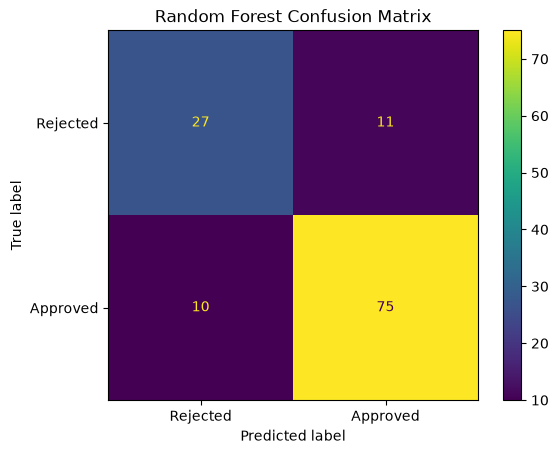

In [608]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Rejected', 'Approved']
).plot()

plt.title('Random Forest Confusion Matrix')
plt.show()

### Confusion Matrix Analysis — Support Vector Machine

Since the Support Vector Machine achieved the highest recall of 92.94%, we will examine its confusion matrix to understand how it achieved this result and what types of errors it made.

### Generate the SVM Confusion Matrix

In [609]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

SVM Confusion Matrix:
[[13 25]
 [ 6 79]]


### Visualize the SVM Confusion Matrix

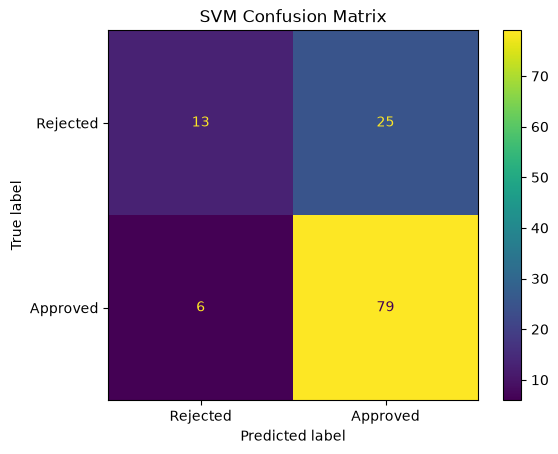

In [610]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=['Rejected', 'Approved']
).plot()

plt.title('SVM Confusion Matrix')
plt.show()

### Confusion Matrix Comparison

The confusion matrices of Random Forest and Support Vector Machine provide additional insight into how the two strongest models behave.

Although SVM achieved the highest recall, Random Forest achieved better overall performance across most of the evaluation metrics.

### Model Selection

After evaluating five classification algorithms using multiple performance metrics and confusion matrices, Random Forest is selected as the final model for the loan approval prediction task.

Random Forest achieved the highest overall performance, with an accuracy of 82.93%, precision of 87.21%, F1-score of 87.72%, and ROC-AUC of 83.68%.

Although SVM achieved a higher recall of 92.94%, it produced substantially more false positives than Random Forest. Therefore, Random Forest provides a stronger overall balance between correctly identifying approved applications and avoiding incorrect approvals.

The selected Random Forest model will be used in the next stages of the project for:

Prediction on unseen data
Model interpretation
Feature importance analysis
Final model documentation

The model selection process demonstrates why evaluating several algorithms using multiple metrics is preferable to selecting a model based on accuracy alone.

### Selected Model

Random Forest Classifier

Accuracy  = 82.93%
Precision = 87.21%
Recall    = 88.24%
F1-Score  = 87.72%
ROC-AUC   = 83.68%

### Prediction on Unseen Data

Now that Random Forest has been selected as the best-performing model, the next stage is to use it to make predictions on unseen loan applications.

The purpose of this stage is to demonstrate how the trained model can be used in a real-world situation where the actual loan outcome is not yet known.

It is important to distinguish between the test dataset used during evaluation and truly unseen data. The test dataset already contains known loan outcomes and was used to evaluate the model. For this stage, we will create predictions for applications without using their actual loan-status values.

### Prepare Unseen Data

The unseen data must go through the same preprocessing steps used during model development.

This includes:

Handling missing values.
Converting Dependents into numerical form.
Creating TotalIncome.
Creating LoanIncomeRatio.
Creating TotalIncomeLog.
Creating LoanAmountLog.
Creating LoanTermYears.
Encoding categorical variables.
Ensuring that the final feature columns match the features used to train the Random Forest model.

The model should never receive raw data in a different format from the data it was trained on.

### Create Predictions

Because Random Forest was trained using the unscaled X_train data, the unseen data should also be provided in the same feature format.

### The original Loan Prediction dataset contains a separate test dataset that does not contain the Loan_Status target variable.

This dataset will be used as the unseen data for the final prediction stage.

Unlike the training and testing datasets used earlier, the actual loan outcomes for these observations are not provided. Therefore, the trained Random Forest model will generate predictions for these applications.

The unseen dataset must undergo the same preprocessing and feature-engineering procedures used during model development to ensure that the model receives features in the same format as the training data.

In [611]:
unseen.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


### Feature Engineering on Unseen Data

The unseen test dataset contains the original loan application variables but does not contain the Loan_Status target variable.

To make predictions using the trained Random Forest model, the same feature-engineering transformations used during model development will be applied to the unseen dataset.

The following features will be created:

TotalIncome
LoanIncomeRatio
TotalIncomeLog
LoanAmountLog
LoanTermYears

The original categorical variables will also be encoded using the same encoding approach used for the training dataset.

This ensures that the unseen data has the same structure and feature representation as the data used to train the Random Forest model.

In [612]:
unseen = unseen.copy()

In [613]:
unseen["TotalIncome"] = (
    unseen["ApplicantIncome"] +
    unseen["CoapplicantIncome"]
)

In [614]:
unseen["LoanIncomeRatio"] = (
    unseen["LoanAmount"] / unseen["TotalIncome"]
)

In [615]:
unseen["TotalIncomeLog"] = np.log1p(
    unseen["TotalIncome"]
)

In [616]:
unseen["LoanAmountLog"] = np.log1p(
    unseen["LoanAmount"]
)

In [617]:
unseen["LoanTermYears"] = (
    unseen["Loan_Amount_Term"] / 12
)

In [618]:
unseen.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,LoanIncomeRatio,TotalIncomeLog,LoanAmountLog,LoanTermYears
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,5720,0.019231,8.651899,4.709530,30.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,4576,0.027535,8.428799,4.844187,30.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,6800,0.030588,8.824825,5.342334,30.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,4886,0.020467,8.494334,4.615121,30.0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,3276,0.023810,8.094684,4.369448,30.0


In [619]:
unseen.info()

<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
 12  TotalIncome        367 non-null    int64  
 13  LoanIncomeRatio    362 non-null    float64
 14  TotalIncomeLog     367 non-null    float64
 15  LoanAmountLog      362 non-null    float64
 16  LoanTermYears      361 non-null    fl

In [620]:
unseen.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
TotalIncome           0
LoanIncomeRatio       5
TotalIncomeLog        0
LoanAmountLog         5
LoanTermYears         6
dtype: int64

In [621]:
unseen["Gender"] = unseen["Gender"].fillna(unseen["Gender"].mode()[0])

unseen["Self_Employed"] = unseen["Self_Employed"].fillna(
    unseen["Self_Employed"].mode()[0]
)

In [622]:
unseen["Dependents"] = unseen["Dependents"].replace("3+", 3)
unseen["Dependents"] = pd.to_numeric(unseen["Dependents"])
unseen["Dependents"] = unseen["Dependents"].fillna(
    unseen["Dependents"].median()
)

In [623]:
unseen["LoanAmount"] = unseen["LoanAmount"].fillna(
    unseen["LoanAmount"].median()
)

unseen["Loan_Amount_Term"] = unseen["Loan_Amount_Term"].fillna(
    unseen["Loan_Amount_Term"].median()
)

unseen["Credit_History"] = unseen["Credit_History"].fillna(
    unseen["Credit_History"].mode()[0]
)

In [624]:
unseen["LoanIncomeRatio"] = (
    unseen["LoanAmount"] / unseen["TotalIncome"]
)

unseen["LoanAmountLog"] = np.log1p(
    unseen["LoanAmount"]
)

unseen["LoanTermYears"] = (
    unseen["Loan_Amount_Term"] / 12
)

In [625]:
unseen.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
TotalIncome          0
LoanIncomeRatio      0
TotalIncomeLog       0
LoanAmountLog        0
LoanTermYears        0
dtype: int64

### Encode the Unseen Data

The categorical variables in the unseen dataset must be converted into numerical variables using the same encoding approach applied to the training data.

The training dataset used one-hot encoding for the categorical variables. To maintain consistency between the training and unseen datasets, the same categories and feature structure will be created for the unseen data.

The Loan_ID column and the original categorical columns that are no longer required will be excluded from the model features.

The final unseen dataset must contain the same 12 predictor variables used to train the Random Forest model and must also have them in the same order.

In [626]:
unseen_encoded = pd.get_dummies(
    unseen,
    columns=[
        "Gender",
        "Married",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True,
    dtype=int
)

In [627]:
unseen_encoded = unseen_encoded.drop(
    columns=["Loan_ID", "ApplicantIncome", "CoapplicantIncome",
             "LoanAmount", "Loan_Amount_Term", "TotalIncome"],
    errors="ignore"
)

In [628]:
model_features = X_train.columns.tolist()

print(model_features)

['Dependents', 'TotalIncomeLog', 'LoanIncomeRatio', 'LoanAmountLog', 'LoanTermYears', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [629]:
X_unseen = unseen_encoded.reindex(
    columns=model_features,
    fill_value=0
)

In [630]:
print(X_unseen.shape)
print(X_unseen.columns.tolist())

(367, 12)
['Dependents', 'TotalIncomeLog', 'LoanIncomeRatio', 'LoanAmountLog', 'LoanTermYears', 'Credit_History', 'Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [631]:
X_unseen.head()

,Dependents,TotalIncomeLog,LoanIncomeRatio,LoanAmountLog,LoanTermYears,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.0,8.651899,0.019231,4.709530,30.0,1.0,1,1,0,0,0,1
1,1.0,8.428799,0.027535,4.844187,30.0,1.0,1,1,0,0,0,1
2,2.0,8.824825,0.030588,5.342334,30.0,1.0,1,1,0,0,0,1
3,2.0,8.494334,0.020467,4.615121,30.0,1.0,1,1,0,0,0,1
4,0.0,8.094684,0.023810,4.369448,30.0,1.0,1,0,1,0,0,1


### Prediction on Unseen Data
The unseen dataset has now been prepared using the same preprocessing, feature engineering, and encoding procedures applied to the training data.

The final dataset contains 367 loan applications and 12 predictor variables, matching the structure used to train the selected Random Forest model.

The trained Random Forest model will now be used to predict the loan status of these unseen applications.

Because the actual Loan_Status values are not available in the unseen dataset, these predictions cannot be evaluated using accuracy, precision, recall, or F1-score. Instead, the model will provide a predicted loan status and an estimated probability of approval for each application.
### Generate Loan Predictions

In [632]:
unseen_predictions = random_forest.predict(X_unseen)

In [633]:
unseen_probabilities = random_forest.predict_proba(X_unseen)[:, 1]

In [634]:
prediction_results = pd.DataFrame({
    "Loan_ID": unseen["Loan_ID"],
    "Predicted_Loan_Status": unseen_predictions,
    "Approval_Probability": unseen_probabilities
})

In [635]:
prediction_results["Predicted_Loan_Status"] = (
    prediction_results["Predicted_Loan_Status"]
    .map({1: "Approved", 0: "Rejected"})
)

In [636]:
prediction_results.head()

,Loan_ID,Predicted_Loan_Status,Approval_Probability
0,LP001015,Approved,0.74
1,LP001022,Approved,0.77
2,LP001031,Approved,0.81
3,LP001035,Approved,0.58
4,LP001051,Rejected,0.48


In [637]:
prediction_results["Predicted_Loan_Status"].value_counts()

Predicted_Loan_Status
Approved    282
Rejected     85
Name: count, dtype: int64

In [638]:
prediction_results["Approval_Probability"].describe()

count    367.000000
mean       0.681226
std        0.238493
min        0.080000
25%        0.550000
50%        0.750000
75%        0.865000
max        1.000000
Name: Approval_Probability, dtype: float64

### Prediction Summary
The trained Random Forest model was applied to the 367 unseen loan applications after completing the same data-cleaning, feature-engineering, and encoding procedures used during model development.

For each unseen application, the model generated:

A predicted loan status.
An estimated probability of loan approval.

The predicted loan status was converted from numerical values into readable categories, where 1 represents Approved and 0 represents Rejected.

The prediction results provide an example of how the trained machine-learning model could be used to support automated loan-approval prediction for new applicants.

Because the actual loan outcomes for the unseen dataset are not available, the predictions cannot be evaluated using accuracy, precision, recall, F1-score, or ROC-AUC. Instead, the predictions and approval probabilities will be used to demonstrate the model's application to previously unseen data.

In [639]:
prediction_results.to_csv(
    "loan_predictions.csv",
    index=False
)

### Random Forest Feature Importance
Feature importance analysis will be used to identify the variables that contributed most to the Random Forest model's predictions.

The Random Forest algorithm provides an importance score for each feature based on its contribution to the model's decision-making process.

These scores will be combined with the corresponding feature names and sorted from the most important feature to the least important feature.

In [640]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

In [641]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [642]:
feature_importance

,Feature,Importance
5,Credit_History,0.211668
1,TotalIncomeLog,0.201633
2,LoanIncomeRatio,0.180605
3,LoanAmountLog,0.171098
0,Dependents,0.052537
4,LoanTermYears,0.046287
10,Property_Area_Semiurban,0.028528
8,Education_Not Graduate,0.023643
11,Property_Area_Urban,0.021900
7,Married_Yes,0.021731


### Feature Importance Analysis

The Random Forest feature importance analysis was performed to identify the variables that contributed most to the model's loan approval predictions.

The results show that Credit History was the most influential feature, with an importance score of 0.2117. This indicates that an applicant's credit history played a major role in the model's decision-making process.

TotalIncomeLog was the second most important feature, with an importance score of 0.2016, followed by LoanIncomeRatio (0.1806) and LoanAmountLog (0.1711). These results indicate that the applicant's income level and the relationship between income and requested loan amount were important factors in the model's predictions.

Dependents (0.0525) and LoanTermYears (0.0463) had moderate levels of importance.

The categorical variables generally had lower importance scores. Property_Area_Semiurban had the highest importance among the encoded categorical variables (0.0285), followed by Education_Not Graduate (0.0236) and Property_Area_Urban (0.0219).

Married_Yes, Self_Employed_Yes, and Gender_Male had relatively low importance scores of 0.0217, 0.0212, and 0.0192, respectively.

Overall, the feature importance analysis suggests that Credit History, income-related features, and loan-related features were substantially more influential than demographic characteristics in the Random Forest model.

These results are consistent with the earlier EDA, where Credit History showed a strong relationship with loan approval.

### Feature Importance Visualization

Visualization to make the ranking easier to communicate.

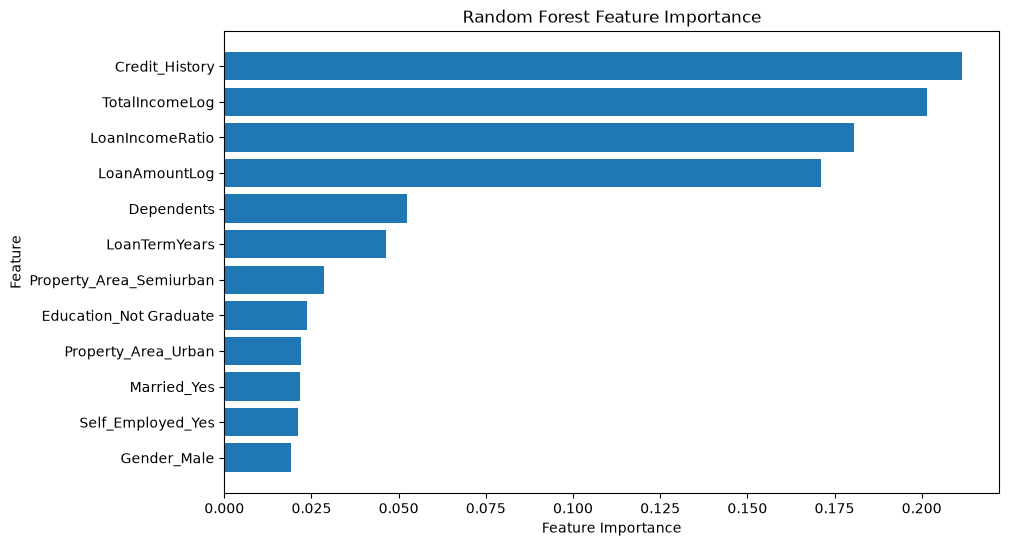

In [643]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

### Final Model Evaluation

The Random Forest Classifier was selected as the final model based on its overall performance across the evaluation metrics.

The model achieved an accuracy of 82.93%, meaning that it correctly classified approximately 83% of the loan applications in the test dataset.

The model also achieved a precision of 87.21%, indicating that most applications predicted as approved were actually approved.

The recall score was 88.24%, showing that the model successfully identified a large proportion of the applications that were actually approved.

The F1-Score of 87.72% demonstrates a strong balance between precision and recall.

The Random Forest model achieved a ROC-AUC score of 83.68%, indicating good ability to distinguish between approved and rejected loan applications.

The confusion matrix further showed that the model correctly classified 102 out of 123 test applications, with 27 true negatives and 75 true positives.

Overall, the results indicate that the Random Forest model provides a strong predictive performance for the loan approval classification task and was therefore selected as the final model.

### Model Interpretation Summary

The model interpretation analysis examined the feature importance scores generated by the Random Forest classifier.

The results indicate that financial and credit-related variables were the most influential factors in the model's predictions. Credit History had the highest feature importance, followed by Total Income Log, Loan Income Ratio, and Loan Amount Log.

Features such as Dependents and Loan Term Years had moderate importance, while the encoded demographic and categorical variables generally had lower importance.

Overall, the feature importance analysis provides additional insight into the factors that the Random Forest model relied on when predicting loan approval.

The findings also support the earlier exploratory data analysis, particularly the strong relationship observed between Credit History and Loan Status.

The next stage will focus on the final model evaluation and project conclusions, bringing together the findings from EDA, feature engineering, model comparison, and model interpretation.

In [644]:
# Display feature importance from highest to lowest
feature_importance

,Feature,Importance
5,Credit_History,0.211668
1,TotalIncomeLog,0.201633
2,LoanIncomeRatio,0.180605
3,LoanAmountLog,0.171098
0,Dependents,0.052537
4,LoanTermYears,0.046287
10,Property_Area_Semiurban,0.028528
8,Education_Not Graduate,0.023643
11,Property_Area_Urban,0.021900
7,Married_Yes,0.021731


In [645]:
top_features = feature_importance.head(5).copy()

top_features["Importance_Percentage"] = (
    top_features["Importance"] * 100
).round(2)

top_features

,Feature,Importance,Importance_Percentage
5,Credit_History,0.211668,21.17
1,TotalIncomeLog,0.201633,20.16
2,LoanIncomeRatio,0.180605,18.06
3,LoanAmountLog,0.171098,17.11
0,Dependents,0.052537,5.25


### Final Conclusion


This project developed a machine-learning model to predict loan approval using applicant demographic, financial, credit, and loan-related information.

The analysis began with data cleaning and exploratory data analysis to understand the characteristics of the applicants and identify relationships between the available variables and loan approval status.

Feature engineering was then performed to create additional variables, including TotalIncome, LoanIncomeRatio, TotalIncomeLog, LoanAmountLog, and LoanTermYears. These transformations helped provide the machine-learning models with additional information about applicants' financial characteristics.

Five classification algorithms were evaluated:

Logistic Regression
Decision Tree
Random Forest
K-Nearest Neighbors
Support Vector Machine

Among the models evaluated, Random Forest achieved the strongest overall performance, with an accuracy of 82.93%, precision of 87.21%, recall of 88.24%, F1-score of 87.72%, and ROC-AUC of 83.68%.

Although Support Vector Machine achieved the highest recall of 92.94%, Random Forest provided a better overall balance between precision, recall, and classification performance.

Feature importance analysis showed that Credit History, Total Income Log, Loan Income Ratio, and Loan Amount Log were the most influential features in the Random Forest model. This indicates that credit and financial characteristics played a more important role in the model's predictions than most demographic variables.

The final Random Forest model was also applied to the unseen loan applications to demonstrate how the model can generate loan approval predictions for new applicants.

Overall, the project demonstrates how exploratory data analysis, feature engineering, SQL analysis, and machine learning can be combined to develop a data-driven approach to loan approval prediction.

The results provide a strong foundation for further improvement through hyperparameter tuning, cross-validation, additional feature engineering, and deployment of the model in a real-world application.

In [646]:
y_pred_rf_proba = random_forest.predict_proba(X_test)[:, 1]

In [647]:
# Create a summary of the final Random Forest model performance

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_rf_proba)
    ]
})

final_results

,Metric,Score
0,Accuracy,0.829268
1,Precision,0.872093
2,Recall,0.882353
3,F1-Score,0.877193
4,ROC-AUC,0.836842


In [648]:
final_results.to_csv(
    "random_forest_final_results.csv",
    index=False
)

In [649]:
feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

### Prepare Data for Power BI

The final cleaned and feature-engineered loan dataset will be prepared for visualization in Power BI.

The Power BI dashboard will combine the key findings from the exploratory data analysis and machine-learning analysis into an interactive business intelligence report.

The dashboard will focus on:

Overall loan approval and rejection rates.
Applicant demographic characteristics.
Income and loan characteristics.
Credit history and its relationship with loan approval.
Property area and education differences.
Key loan approval KPIs.
Model-related insights where appropriate.

The cleaned dataset will be exported from Python and imported into Power BI for dashboard development.

In [650]:
powerbi_data = df.copy()

In [651]:
powerbi_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,LoanIncomeRatio,TotalIncomeLog,LoanAmountLog,LoanTermYears
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.021884,8.674197,4.859812,30.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.021015,8.714732,4.859812,30.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.022000,8.006701,4.204693,30.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.024287,8.505525,4.795791,30.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.023500,8.699681,4.955827,30.0


In [652]:
powerbi_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
 13  TotalIncome        614 non-null    float64
 14  LoanIncomeRatio    614 non-null    float64
 15  TotalIncomeLog     614 non-null    float64
 16  LoanAmountLog      614 non-null    fl

In [653]:
powerbi_data.shape

(614, 18)

In [654]:
powerbi_data.to_csv(
    "loan_powerbi_data.csv",
    index=False
)

In [655]:
import os

os.path.exists("loan_powerbi_data.csv")

True